# Portfolio allocation analysis

This notebook loads `data.csv`, summarizes the current portfolio, and visualizes the allocations by sector and by account type.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

plt.style.use("ggplot")

CLASSIFICATION_MAP = {
    "AMBA": "semiconductors",
    "AMD": "semiconductors",
    "BABA": "china_tech",
    "BAC": "financials",
    "BIDU": "china_tech",
    "BTC-USD": "crypto",
    "BTI": "tobacco",
    "CASH": "cash",
    "CPT": "real_estate",
    "DDOG": "tech",
    "DKNG": "gambling",
    "ETH-USD": "crypto",
    "FBTC": "crypto",
    "FDGRX": "growth_fund",
    "FDRXX": "cash",
    "GOOGL": "communications",
    "IBM": "tech",
    "JNJ": "healthcare",
    "MSFT": "tech",
    "NVDA": "semiconductors",
    "SOFI": "financials",
    "SPAXX": "cash",
    "VFIAX": "broad_market_etf",
    "VGT": "tech",
    "VIGAX": "growth_fund",
    "VMFXX": "cash",
    "VOO": "broad_market_etf",
}

DATA_PATH = Path("data.csv")
df = pd.read_csv(DATA_PATH)
df["value"] = pd.to_numeric(df["value"])

if "classification" not in df.columns:
    df["classification"] = df["ticker"].map(CLASSIFICATION_MAP).fillna("unclassified")
else:
    df["classification"] = df["classification"].fillna(
        df["ticker"].map(CLASSIFICATION_MAP)
    ).fillna("unclassified")

display(df)
print(f"Total portfolio value: ${df['value'].sum():,.2f}")

,ticker,num_shares,broker,type,value,classification
0,AMBA,11.000000,Schwab,brokerage,583.770000,semiconductors
1,BABA,10.000000,Schwab,brokerage,1318.700000,china_tech
2,BAC,142.664700,Schwab,brokerage,6883.571775,financials
3,BIDU,5.000000,Schwab,brokerage,600.350000,china_tech
4,BTI,20.234300,Schwab,brokerage,1169.340197,tobacco
5,CPT,5.450100,Schwab,brokerage,579.400131,real_estate
6,DDOG,3.000000,Schwab,brokerage,376.320000,tech
7,DKNG,102.000000,Schwab,brokerage,2552.040000,gambling
8,GOOGL,11.081400,Schwab,brokerage,3314.557554,communications
9,IBM,44.000000,Schwab,brokerage,11255.380400,tech


Total portfolio value: $317,679.48


## Sector allocation

This pie chart groups holdings by the `classification` column so you can see portfolio exposure by sector or theme.

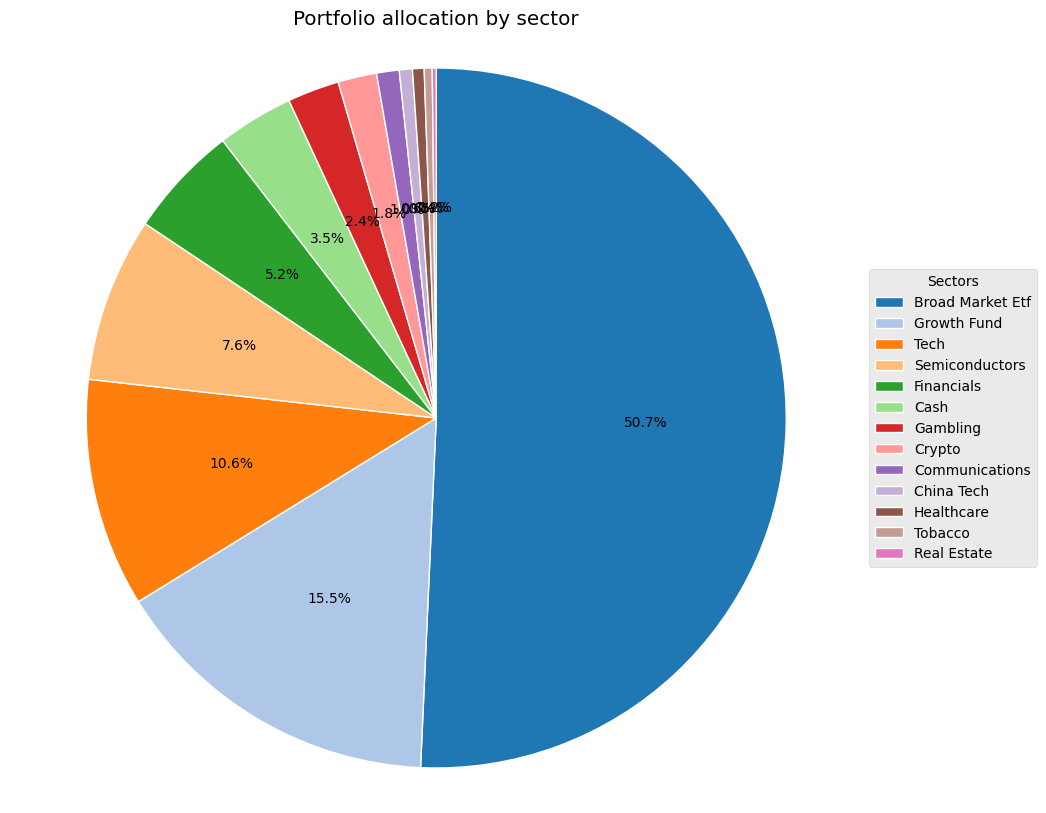

,sector,value
0,Broad Market Etf,161108.728413
7,Growth Fund,49211.983750
11,Tech,33550.130770
10,Semiconductors,24154.698725
5,Financials,16484.771775
1,Cash,11205.680000
6,Gambling,7601.704875
4,Crypto,5679.470514
3,Communications,3314.557554
2,China Tech,1919.050000


In [2]:
sector_totals = (
    df.groupby("classification", as_index=False)["value"]
    .sum()
    .sort_values("value", ascending=False)
)
sector_totals["label"] = sector_totals["classification"].str.replace("_", " ").str.title()

classification_order = sector_totals["classification"].tolist()
palette = plt.cm.tab20.colors
sector_color_map = {
    classification: palette[i % len(palette)]
    for i, classification in enumerate(classification_order)
}
sector_colors = [sector_color_map[classification] for classification in sector_totals["classification"]]

fig, ax = plt.subplots(figsize=(11, 10))
wedges, _, _ = ax.pie(
    sector_totals["value"],
    labels=None,
    colors=sector_colors,
    autopct="%1.1f%%",
    startangle=90,
    counterclock=False,
    wedgeprops={"linewidth": 1, "edgecolor": "white"},
)
ax.set_title("Portfolio allocation by sector")
ax.axis("equal")
ax.legend(
    wedges,
    sector_totals["label"],
    title="Sectors",
    loc="center left",
    bbox_to_anchor=(1.0, 0.5),
)
plt.show()

display(sector_totals[["label", "value"]].rename(columns={"label": "sector"}))

## Sector allocation by account type

Each chart shows the sector mix for one investment account type across all brokers, so you can compare taxable, Roth, HSA, and other account buckets directly.

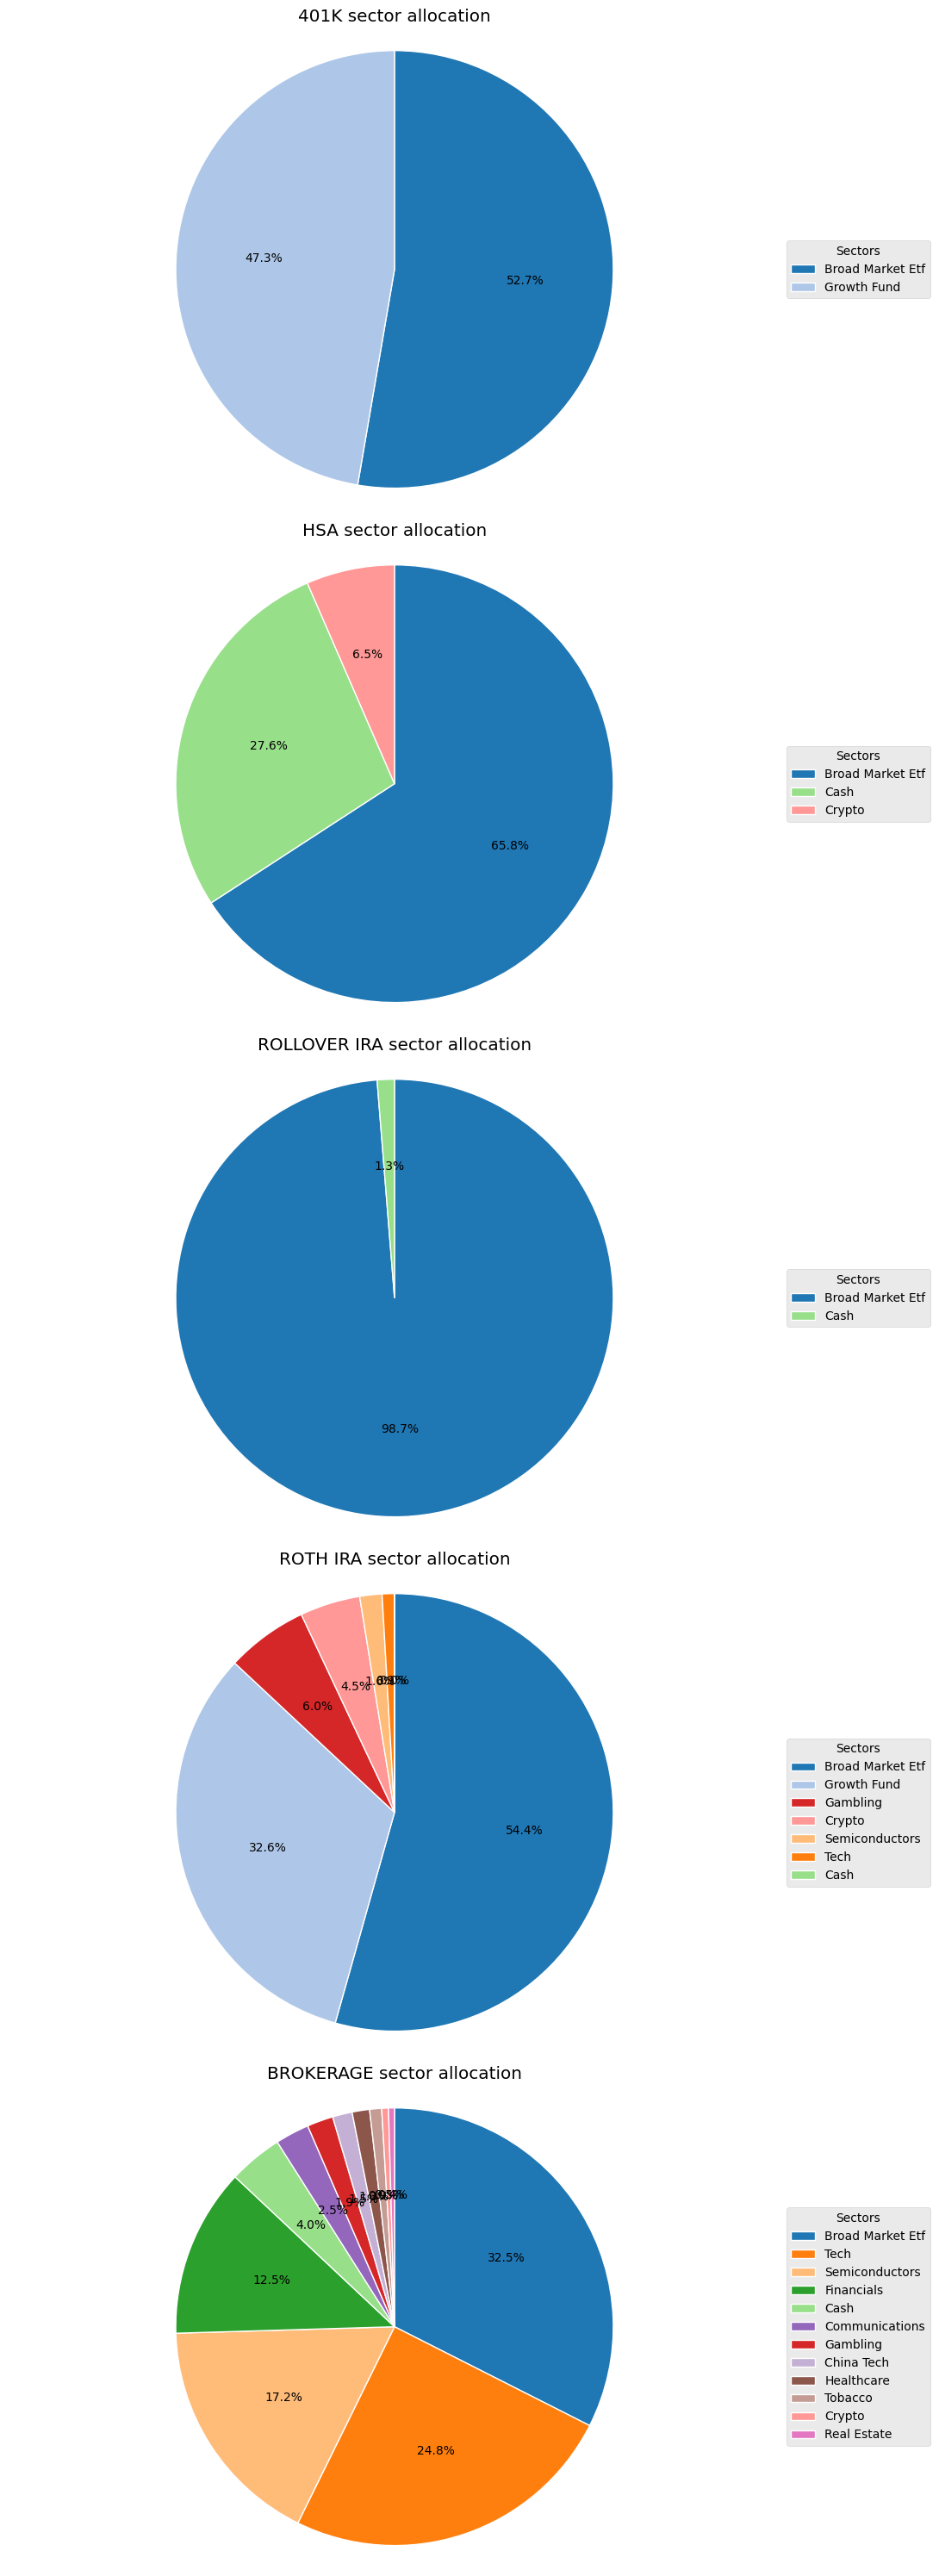

,type,sector,value
0,401K,Broad Market Etf,24426.329100
1,401K,Growth Fund,21925.621500
2,HSA,Broad Market Etf,13024.066560
3,HSA,Cash,5469.980000
4,HSA,Crypto,1290.703800
5,ROLLOVER IRA,Broad Market Etf,35254.073460
6,ROLLOVER IRA,Cash,453.970000
7,ROTH IRA,Broad Market Etf,45518.152317
11,ROTH IRA,Growth Fund,27286.362250
10,ROTH IRA,Gambling,5049.664875


In [3]:
account_sector_totals = (
    df.groupby(["type", "classification"], as_index=False)["value"]
    .sum()
    .sort_values(["type", "value"], ascending=[True, False])
)
account_sector_totals["account_type"] = account_sector_totals["type"].str.upper()
account_sector_totals["sector_label"] = (
    account_sector_totals["classification"].str.replace("_", " ").str.title()
)

account_types = account_sector_totals["type"].drop_duplicates().tolist()
fig, axes = plt.subplots(len(account_types), 1, figsize=(11, 6 * len(account_types)))
if len(account_types) == 1:
    axes = [axes]

for ax, account_type in zip(axes, account_types):
    account_data = account_sector_totals[account_sector_totals["type"] == account_type]
    colors = [sector_color_map[classification] for classification in account_data["classification"]]
    wedges, _, _ = ax.pie(
        account_data["value"],
        labels=None,
        colors=colors,
        autopct="%1.1f%%",
        startangle=90,
        counterclock=False,
        wedgeprops={"linewidth": 1, "edgecolor": "white"},
    )
    ax.set_title(f"{account_type.upper()} sector allocation")
    ax.axis("equal")
    ax.legend(
        wedges,
        account_data["sector_label"],
        title="Sectors",
        loc="center left",
        bbox_to_anchor=(1.0, 0.5),
    )

plt.tight_layout()
plt.show()

display(
    account_sector_totals[["account_type", "sector_label", "value"]].rename(
        columns={"account_type": "type", "sector_label": "sector"}
    )
)